In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

#################################
# Part 1: Training and Saving
#################################

def load_ecg_data(directory, num_files, usecols=0):
    """
    Load ECG files from a directory.
    
    Parameters:
      directory (str): Path to the dataset directory.
      num_files (int): Number of files to load.
      usecols (int or sequence): Which column(s) to load. Here we use 0 to load only lead I.
      
    Returns:
      list of 1D numpy arrays of shape (5000,)
    """
    data = []
    for i in range(num_files):
        file_path = os.path.join(directory, f"{i}.asc")
        try:
            # Only load the first column from each file.
            ecg = np.loadtxt(file_path, usecols=usecols)
            data.append(ecg)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return data

# Paths to the datasets.
synthetic_path = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/cnn_fake"
real_path = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"

# Load datasets.
# For synthetic: files have 8 columns, for real: 12 columns. We only need the first column.
synthetic_ecgs = load_ecg_data(synthetic_path, 1000, usecols=0)  # Each file returns shape (5000,)
real_ecgs = load_ecg_data(real_path, 1000, usecols=0)            # Each file returns shape (5000,)

# Reshape to add the feature dimension for the LSTM.
# After this, each sample becomes (5000, 1)
synthetic_ecgs = np.array(synthetic_ecgs)[..., np.newaxis]  # Shape: (1000, 5000, 1)
real_ecgs = np.array(real_ecgs)[..., np.newaxis]            # Shape: (1000, 5000, 1)

# Normalize each signal between -1 and 1 using MinMaxScaler.
def scale_signals(signals):
    scaled_signals = []
    scaler = MinMaxScaler(feature_range=(-1, 1))
    for sig in signals:
        # Each sig has shape (5000, 1)
        sig_scaled = scaler.fit_transform(sig)
        scaled_signals.append(sig_scaled)
    return np.array(scaled_signals)

synthetic_ecgs_scaled = scale_signals(synthetic_ecgs)
real_ecgs_scaled = scale_signals(real_ecgs)

# Use the real ECGs as "normal" data for training.
real_train, real_test = train_test_split(real_ecgs_scaled, test_size=0.2, random_state=42)

# Build the LSTM-Autoencoder.
timesteps = 5000  # each ECG signal length
n_features = 1

model = Sequential()
# Encoder
model.add(LSTM(128, activation='relu', return_sequences=True, input_shape=(timesteps, n_features)))
model.add(LSTM(64, activation='relu', return_sequences=False))
# Bottleneck
model.add(RepeatVector(timesteps))
# Decoder
model.add(LSTM(64, activation='relu', return_sequences=True))
model.add(LSTM(128, activation='relu', return_sequences=True))
model.add(TimeDistributed(Dense(n_features)))
model.compile(optimizer='adam', loss='mse')

model.summary()

# Train the model.
epochs = 4
batch_size = 32
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(real_train, real_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1,
                    callbacks=[early_stop],
                    shuffle=True)

# Save the trained model.
model_save_path = "ecg_lstm_autoencoder.h5"
model.save(model_save_path)
print(f"Trained model saved to {model_save_path}")

# Compute reconstruction error on the real test set to set a threshold.
def compute_mse(original, reconstructed):
    return np.mean(np.power(original - reconstructed, 2), axis=(1, 2))

real_test_pred = model.predict(real_test)
real_mse = compute_mse(real_test, real_test_pred)
threshold = np.percentile(real_mse, 95)  # 95th percentile threshold
print("Anomaly detection threshold (95th percentile):", threshold)

#################################
# Part 2: Inference and Detection
#################################

# A simple moving average filter for noise estimation.
def moving_average(signal, window_size=50):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

def noise_level(signal, window_size=50):
    """
    Compute a simple noise level metric as the standard deviation of the residuals
    between the signal and its moving average.
    """
    ma = moving_average(signal, window_size)
    noise = signal - ma
    return np.std(noise)

def detect_ecg(file_path, model, threshold, noise_threshold=None, window_size=50):
    """
    Loads an ECG file, preprocesses it (using only the first column), runs anomaly detection,
    computes a noise metric, and plots the results.
    
    Parameters:
        file_path (str): Path to the ECG file (.asc).
        model: Trained LSTM-Autoencoder model.
        threshold (float): Reconstruction error threshold for anomaly detection.
        noise_threshold (float): Optional threshold for noise detection.
        window_size (int): Window size for moving average (noise detection).
    """
    # Load only the first column.
    try:
        ecg = np.loadtxt(file_path, usecols=0)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return

    # Reshape and scale the signal.
    ecg = ecg.reshape(-1, 1)  # shape: (5000, 1)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    ecg_scaled = scaler.fit_transform(ecg)
    
    # Add batch dimension.
    ecg_scaled = np.expand_dims(ecg_scaled, axis=0)  # shape: (1, 5000, 1)
    
    # Predict/reconstruct using the autoencoder.
    ecg_pred = model.predict(ecg_scaled)
    
    # Compute reconstruction error.
    mse = np.mean(np.power(ecg_scaled - ecg_pred, 2))
    
    # Compute noise level.
    noise_std = noise_level(ecg_scaled.flatten(), window_size=window_size)
    
    # Decide if the signal is anomalous.
    is_anomalous = mse > threshold
    anomaly_msg = "Anomalous (possibly synthetic)" if is_anomalous else "Normal (likely real)"
    
    print(f"File: {file_path}")
    print(f"Reconstruction error (MSE): {mse:.6f}")
    print(f"Anomaly decision based on reconstruction error: {anomaly_msg}")
    print(f"Noise level (std of residual): {noise_std:.6f}")
    
    if noise_threshold is not None:
        noise_msg = ("Too clean / unnatural" 
                     if noise_std < noise_threshold 
                     else "Contains typical noise")
        print(f"Noise detection: {noise_msg} (threshold: {noise_threshold})")
    
    # Plot original vs reconstructed signal.
    plt.figure(figsize=(12, 4))
    plt.plot(ecg_scaled.flatten(), label='Original ECG')
    plt.plot(ecg_pred.flatten(), label='Reconstructed ECG')
    plt.title(f"ECG Signal: {os.path.basename(file_path)}")
    plt.legend()
    plt.show()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 5000, 128)         66560     
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 repeat_vector (RepeatVecto  (None, 5000, 64)          0         
 r)                                                              
                                                                 
 lstm_2 (LSTM)               (None, 5000, 64)          33024     
                                                                 
 lstm_3 (LSTM)               (None, 5000, 128)         98816     
                                                                 
 time_distributed (TimeDist  (None, 5000, 1)           129       
 ributed)                                               

c:\Users\M2-Winterfell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


7/7 [==============================] - 25s 3s/step
Anomaly detection threshold (95th percentile): 0.2694407392537054


In [ ]:
# Example usage after training:
# Load the model from disk.
trained_model = load_model("C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/systems/ecg_lstm_autoencoder.h5")
print("Loaded trained model from disk.")

Loaded trained model from disk.


1/1 [==============================] - 1s 1s/step
File: C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/timegan_fake/9.asc
Reconstruction error (MSE): 0.206912
Anomaly decision based on reconstruction error: Normal (likely real)
Noise level (std of residual): 0.165157
Noise detection: Contains typical noise (threshold: 0.05)


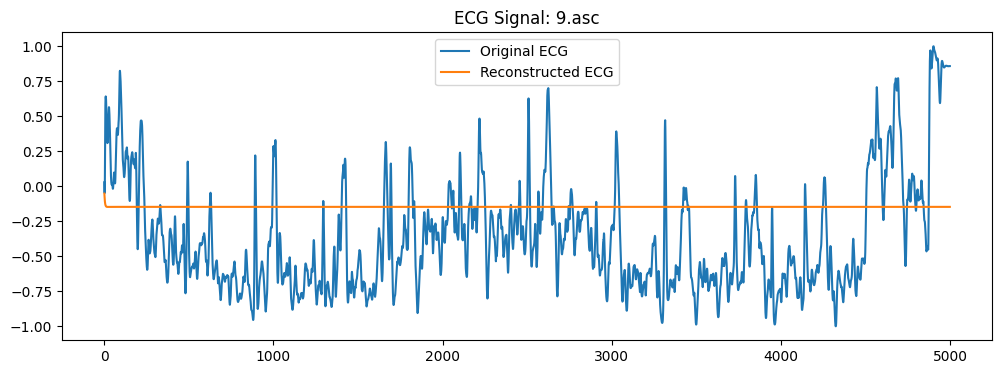

In [5]:

# Provide the path to a new ECG file to test.
test_ecg_path = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/timegan_fake/9.asc"

# Uncomment the following line to run detection on a new ECG file.
detect_ecg(test_ecg_path, trained_model, threshold, noise_threshold=0.05)